In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [3]:
help(torch.jit.load)

Help on function load in module torch.jit._serialization:

load(f, map_location=None, _extra_files=None, _restore_shapes=False)
    Load a :class:`ScriptModule` or :class:`ScriptFunction` previously saved with :func:`torch.jit.save <torch.jit.save>`.
    
    All previously saved modules, no matter their device, are first loaded onto CPU,
    and then are moved to the devices they were saved from. If this fails (e.g.
    because the run time system doesn't have certain devices), an exception is
    raised.
    
    Args:
        f: a file-like object (has to implement read, readline, tell, and seek),
            or a string containing a file name
        map_location (string or torch.device): A simplified version of
            ``map_location`` in `torch.jit.save` used to dynamically remap
            storages to an alternative set of devices.
        _extra_files (dictionary of filename to content): The extra
            filenames given in the map would be loaded and their content
   

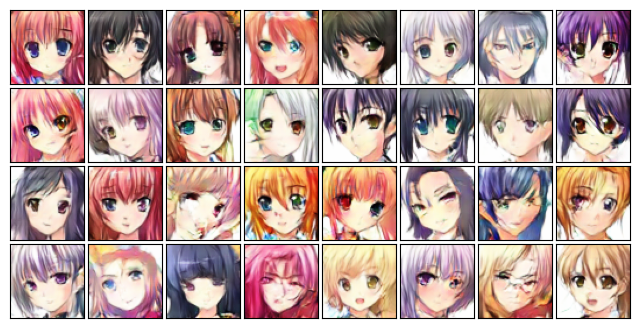

In [14]:
new_G = torch.jit.load(r'C:\Users\moneyforever\Desktop\Deep-Learning\Kaggle\animation_gan\model\anime_gan.pt', map_location = device)
new_G.eval()
noise = torch.randn(32, 100, 1, 1).to(device)
fake_samples = new_G(noise).cpu().detach()
plt.figure(figsize=(8, 4))
for i in range(32):
    ax = plt.subplot(4, 8, i+1)
    img = (fake_samples.cpu().detach()[i] / 2 + 0.5).permute(1, 2, 0)
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    
plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()